# Binomial Tree Option Pricing

## 1. Research Objective

This notebook investigates the binomial tree model for pricing European call and put options. We begin by deriving the Cox-Ross-Rubinstein binomial model, and implement a recombining price tree in Python. 

## 2. Import Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import norm

We also need to reintroduce the Black-Scholes formulas from the previous notebook:

In [4]:
def calculate_d1(S0, K, r, T, sigma):
    d1 = (np.log(S0 / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    return d1


def calculate_d2(S0, K, r, T, sigma):
    d1 = calculate_d1(S0, K, r, T, sigma)
    d2 = d1 - sigma * np.sqrt(T)
    return d2


def black_scholes_call(S0, K, r, T, sigma):
    d1 = calculate_d1(S0, K, r, T, sigma)
    d2 = calculate_d2(S0, K, r, T, sigma)
    call_price = S0 * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    return call_price


def black_scholes_put(S0, K, r, T, sigma):
    d1 = calculate_d1(S0, K, r, T, sigma)
    d2 = calculate_d2(S0, K, r, T, sigma)
    put_price = K * np.exp(-r * T) * norm.cdf(-d2) - S0 * norm.cdf(-d1)
    return put_price

## 3. The Binomial Model



The binomial model assumes that the asset price can move either up or down beginning from some asset price $S_0$. As the asset progresses through time, these movements generate a tree of possible future asset prices: we call this model 'recombining'. The option payoff is first calculated at maturity, after which the value is worked backwords through the tree under the risk-neutral probabilities and discounting.

## 4. One-Period Binomial Model

### 4.1 Theory

Suppose the current asset price is $S_0$, then after one period it can rise to $S_u = S_0u$ or fall to $S_d=S_0d$ where $u$ and $d$ are the upward and downward movement factors. For a European call option, the terminal payoffs are:

$C_u = \max(S_u - K,0)$ and $C_d = \max(S_d - K,0) $

The option value today is calculated as the discounted expected option payoff under the risk-neutral probability measure, which we call the one-period call price:

$ C_0 = e^{-r \Delta t} \left[pC_u + (1-p)C_d\right] $

where $p$ is the risk-neutral probability of an upward movement. 

The one-period put option: 

$ P_0 = e^{-r \Delta t} \left[pP_u + (1-p)P_d\right] $

where $P_u = max(K - S_0u,0) $ and $P_d = max(K-S_0d,0)$

## 5. Cox-Ross-Rubinstein Model

The one-period binomial model lacks depth as real options typically have many opportunities for changes in the underlying asset price before maturity, so we require a multi-period model. This leads us to the Cox-Ross-Rubinstein (CRR) model, which extends the one-period model by dividing the option's time to maturity into a large number of equal time steps, allowing the stock price to evolve through a recombining binomial tree.

### 5.1 CRR Model Parameters

In the CRR model, the option's time to maturity $T$ is divided into $N$ equal time steps such that;

$$ \Delta t = \frac{T}{N} $$

Now, if the stock price is $S$ then after an upward movement $S_u = Su$ and after a downward movement $S_d=Sd$ where $u=e^{\sigma\sqrt{\Delta t}}$ and $d=e^{-\sigma\sqrt{\Delta t}}=1/u$, hence $ud=1$. 

We also need to define the risk neutral probability as:

$$ p = \frac{e^{r \Delta t}-d}{u-d} $$

Another propert is the no-arbitrage condition: $ d < e{r \Delta t} < u $

## 6. Multi-Step Binomial Tree

We have outlined the parameters of the CRR model, so now we can begin to construct the complete stock price tree

At time step $i$, the stock will have experienced $j$ upward movements and $i-j$ downward movements , such that the stock price is:

$$ S_{i-j} = S_0 u^j d^{i-j} $$

In [6]:
# Model 

# We introduce a basic example

S0 = 100
K = 100
r = 0.05
sigma = 0.20
T = 1
N = 5

dt = T / N

u = np.exp(sigma * np.sqrt(dt))
d = np.exp(-sigma * np.sqrt(dt))

p = (np.exp(r * dt) - d) / (u - d)

In [7]:
stock_tree = np.full((N + 1, N + 1), np.nan)

for i in range(N + 1):
    for j in range(i + 1):
        stock_tree[j, i] = S0 * (u ** j) * (d ** (i - j))

stock_tree

array([[100.        ,  91.44406436,  83.62016907,  76.46568122,
         69.92332675,  63.94073192],
       [         nan, 109.35646911, 100.        ,  91.44406436,
         83.62016907,  76.46568122],
       [         nan,          nan, 119.58837337, 109.35646911,
        100.        ,  91.44406436],
       [         nan,          nan,          nan, 130.77762259,
        119.58837337, 109.35646911],
       [         nan,          nan,          nan,          nan,
        143.01379046, 130.77762259],
       [         nan,          nan,          nan,          nan,
                 nan, 156.39483159]])

In [8]:
stock_tree_df = pd.DataFrame(
    stock_tree,
    columns=[f"Step {i}" for i in range(N + 1)],
    index=[f"{j} Up Moves" for j in range(N + 1)]
)

stock_tree_df.round(2)

,Step 0,Step 1,Step 2,Step 3,Step 4,Step 5
0 Up Moves,100.0,91.44,83.62,76.47,69.92,63.94
1 Up Moves,NaN,109.36,100.00,91.44,83.62,76.47
2 Up Moves,NaN,NaN,119.59,109.36,100.00,91.44
3 Up Moves,NaN,NaN,NaN,130.78,119.59,109.36
4 Up Moves,NaN,NaN,NaN,NaN,143.01,130.78
5 Up Moves,NaN,NaN,NaN,NaN,NaN,156.39


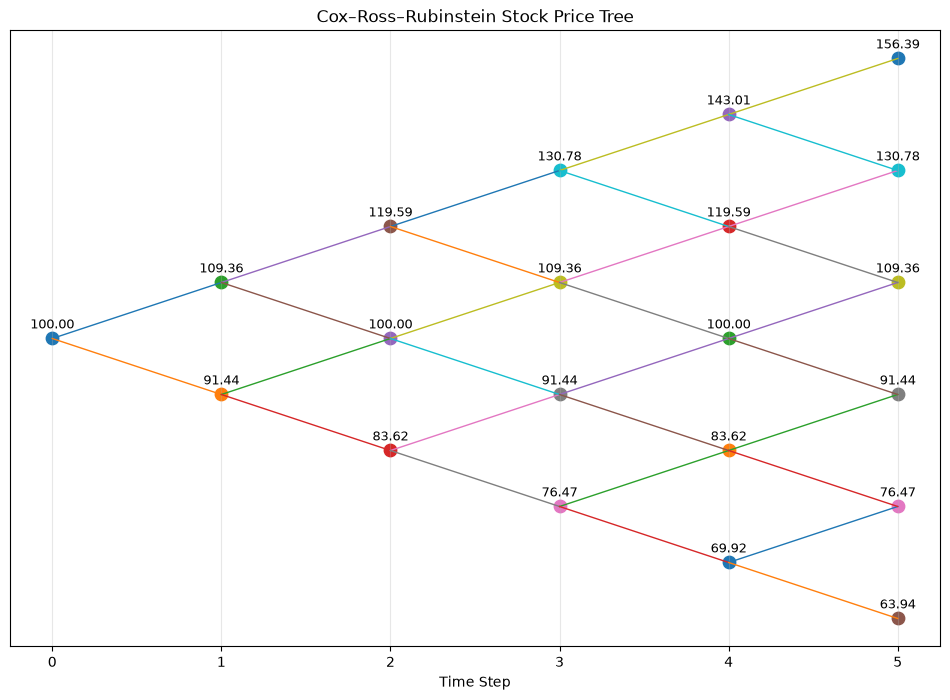

In [9]:
plt.figure(figsize=(12, 8))

for i in range(N):
    for j in range(i + 1):

        current_y = 2 * j - i
        up_y = 2 * (j + 1) - (i + 1)
        down_y = 2 * j - (i + 1)

        plt.plot(
            [i, i + 1],
            [current_y, up_y],
            linewidth=1
        )

        plt.plot(
            [i, i + 1],
            [current_y, down_y],
            linewidth=1
        )

for i in range(N + 1):
    for j in range(i + 1):

        y = 2 * j - i

        plt.scatter(i, y, s=80)

        plt.text(
            i,
            y + 0.18,
            f"{stock_tree[j, i]:.2f}",
            ha="center",
            fontsize=9
        )

plt.title("Cox–Ross–Rubinstein Stock Price Tree")
plt.xlabel("Time Step")
plt.xticks(range(N + 1))
plt.yticks([])
plt.grid(alpha=0.3)
plt.show()

As we can see the binomial tree is recombining, as an upward movement followed by a downward movement produces the original stock price, hence there are $N+1$ unique stock prices at maturity.

In [10]:
terminal_prices = stock_tree[:N + 1, N]

terminal_prices

array([ 63.94073192,  76.46568122,  91.44406436, 109.35646911,
       130.77762259, 156.39483159])

In [11]:
terminal_prices_df = pd.DataFrame({
    "Upward Moves": np.arange(N + 1),
    "Downward Moves": N - np.arange(N + 1),
    "Terminal Stock Price": terminal_prices
})

terminal_prices_df.round(2)

,Upward Moves,Downward Moves,Terminal Stock Price
0,0,5,63.94
1,1,4,76.47
2,2,3,91.44
3,3,2,109.36
4,4,1,130.78
5,5,0,156.39


We have previously discussed the payoff of European call/put options at maturity, so let us now compute these.

In [13]:
call_payoffs = np.maximum(terminal_prices - K, 0)

put_payoffs = np.maximum(K - terminal_prices, 0)

payoff_df = pd.DataFrame({
    "Terminal Stock Price": terminal_prices,
    "Call Payoff": call_payoffs,
    "Put Payoff": put_payoffs
})

payoff_df.round(2)

,Terminal Stock Price,Call Payoff,Put Payoff
0,63.94,0.00,36.06
1,76.47,0.00,23.53
2,91.44,0.00,8.56
3,109.36,9.36,0.00
4,130.78,30.78,0.00
5,156.39,56.39,0.00


The call option has a positive payoff when the terminal stock price exceeds the strike price. 

The put option has a positive payoff when the terminal stock price is below the strike price.

These values represent the option payoffs at maturity. To determine the option value today, the terminal payoffs must be moved backwards through the tree using risk-neutral valuation.

This process is known as backward induction and is developed in the next chapter.